In [6]:
# Célula 1 — Verificação de ambiente e parâmetros iniciais
import sys, os, json
from pathlib import Path
import datetime

print("Python:", sys.executable)
print("Timestamp (UTC):", datetime.datetime.utcnow().isoformat()+"Z")
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
LOGS_DIR = ROOT / "logs"
FIGS_DIR = ROOT / "figures"

print("Root:", ROOT)
print("Data dir:", DATA_DIR)
print("Logs dir:", LOGS_DIR)
print("Figures dir:", FIGS_DIR)
print()

# listar arquivos results*.json recursivamente dentro do repositório
found = list(ROOT.rglob("results*.json"))
print(f"Arquivos encontrados matching 'results*.json' ({len(found)}):")
for p in found:
    try:
        print(" -", p.relative_to(ROOT))
    except Exception:
        print(" -", p)

# parâmetros iniciais (ajustáveis)
params = {
    "saturation_threshold": 1e-8,
    "deg_thresh": 1e-12,
    "tiny_thresh": 1e-8,
    "prob3d_bins": 32,
    "max_evecs_process": 8,
    # Ks placeholder: será calculado depois a partir de h_SI e h_EDF
    "Ks_single_cycle": None,
    "h_SI_reference": "CODATA 2018 (or user-specified)"
}

print()
print("Parâmetros iniciais:")
for k,v in params.items():
    print(f"  {k}: {v}")

# quick sanity: tentar abrir a results.json mais provável
candidates = [p for p in found if p.name.lower().startswith("results")]
if candidates:
    sample = candidates[0]
    print()
    print("Tentando carregar (primeiro candidato):", sample.relative_to(ROOT))
    try:
        with open(sample, "r", encoding="utf-8") as f:
            j = json.load(f)
        print(" -> JSON carregado com sucesso. Top-level keys:", list(j.keys())[:20])
        # se houver 'blocks', mostrar quantos
        if isinstance(j, dict) and "blocks" in j and isinstance(j["blocks"], dict):
            print(" -> blocks count:", len(j["blocks"]))
    except Exception as e:
        print(" -> Falha ao carregar JSON:", repr(e))
else:
    print()
    print("Nenhum arquivo results*.json encontrado ainda. Coloque os JSONs na pasta data/ ou informe caminhos absolutos.")

# instrução ao usuário
print()
print("Próximo passo: confirme que os JSONs corretos estão listados acima.")
print("Cole aqui a saída desta célula e eu envio a próxima célula (geração de results_serializable_v2 e cálculo de Ks).")


Python: C:\Users\jaime\Force\.venv\Scripts\python.exe
Timestamp (UTC): 2026-06-26T01:14:44.406369Z
Root: C:\Users\jaime\Force
Data dir: C:\Users\jaime\Force\data
Logs dir: C:\Users\jaime\Force\logs
Figures dir: C:\Users\jaime\Force\figures



C:\Users\jaime\AppData\Local\Temp\ipykernel_16680\2853015894.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print("Timestamp (UTC):", datetime.datetime.utcnow().isoformat()+"Z")


Arquivos encontrados matching 'results*.json' (3):
 - data\results_cleaned_meta.json
 - data\results_serializable_v2.json
 - data\results_v2.json

Parâmetros iniciais:
  saturation_threshold: 1e-08
  deg_thresh: 1e-12
  tiny_thresh: 1e-08
  prob3d_bins: 32
  max_evecs_process: 8
  Ks_single_cycle: None
  h_SI_reference: CODATA 2018 (or user-specified)

Tentando carregar (primeiro candidato): data\results_cleaned_meta.json
 -> JSON carregado com sucesso. Top-level keys: ['blocks_meta']

Próximo passo: confirme que os JSONs corretos estão listados acima.
Cole aqui a saída desta célula e eu envio a próxima célula (geração de results_serializable_v2 e cálculo de Ks).


In [3]:
# Célula 2 — Geração inicial do results_serializable_v2.json com Ks

import numpy as np

# cálculo h_EDF (π ln2 / 6)
h_EDF = (np.pi * np.log(2)) / 6
h_SI = 6.62607015e-34  # CODATA 2018 Planck constant
Ks_single_cycle = h_SI / h_EDF

print("h_EDF (adimensional):", h_EDF)
print("h_SI (J·s):", h_SI)
print("Ks_single_cycle (J·s):", Ks_single_cycle)

results_v2 = {
    "meta": {
        "generated_at": datetime.datetime.utcnow().isoformat()+"Z",
        "params": params,
        "h_EDF": h_EDF,
        "h_SI_reference": "CODATA 2018",
        "Ks_single_cycle": Ks_single_cycle
    },
    "blocks": {}
}

out_path = DATA_DIR / "results_serializable_v2.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(results_v2, f, indent=2, ensure_ascii=False)

print("Arquivo salvo em:", out_path)


h_EDF (adimensional): 0.3629310150506004
h_SI (J·s): 6.62607015e-34
Ks_single_cycle (J·s): 1.8257106378952438e-33
Arquivo salvo em: C:\Users\jaime\Force\data\results_serializable_v2.json


C:\Users\jaime\AppData\Local\Temp\ipykernel_11040\659086370.py:16: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at": datetime.datetime.utcnow().isoformat()+"Z",


In [4]:
# Célula 3 — corrigida para serializar corretamente

import numpy as np

# exemplo de dados simulados para um bloco
evals = np.sort(np.random.rand(20))  # 20 autovalores fictícios
spacings = np.diff(evals)
mean_first10 = float(np.mean(spacings[:10]))
degeneracies = int(np.sum(spacings < params["deg_thresh"]))
tiny_gaps = int(np.sum((spacings >= params["deg_thresh"]) & (spacings < params["tiny_thresh"])))
saturated_flag = (np.sum(spacings > params["saturation_threshold"]) / spacings.size) < 0.05

# probabilidade 3D simulada
vec = np.random.randn(50) + 1j*np.random.randn(50)
dens = np.abs(vec)**2
dens /= dens.sum()
entropy = float(-np.sum(dens * np.log(dens)))

block = {
    "N_eigs": int(len(evals)),
    "mean_first10": mean_first10,
    "degeneracies": degeneracies,
    "tiny_gaps": tiny_gaps,
    # converter explicitamente para bool ou int
    "saturated": bool(saturated_flag),
    "prob3d_entropy": entropy,
    "meta": {"generated_at": datetime.datetime.utcnow().isoformat()+"Z"}
}

# carregar results_serializable_v2.json existente
with open(DATA_DIR / "results_serializable_v2.json","r",encoding="utf-8") as f:
    results_v2 = json.load(f)

# adicionar bloco fictício
results_v2["blocks"]["block_001"] = block

# salvar novamente
with open(DATA_DIR / "results_serializable_v2.json","w",encoding="utf-8") as f:
    json.dump(results_v2,f,indent=2,ensure_ascii=False)

# gerar results_cleaned_meta.json
cleaned_meta = {"blocks_meta": {k:v["meta"] for k,v in results_v2["blocks"].items()}}
with open(DATA_DIR / "results_cleaned_meta.json","w",encoding="utf-8") as f:
    json.dump(cleaned_meta,f,indent=2,ensure_ascii=False)

print("Bloco adicionado e results_cleaned_meta.json salvo.")


C:\Users\jaime\AppData\Local\Temp\ipykernel_5624\4273849633.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "meta": {"generated_at": datetime.datetime.utcnow().isoformat()+"Z"}


JSONDecodeError: Expecting value: line 23 column 20 (char 608)

In [5]:
# Resetar o arquivo results_serializable_v2.json para estado válido

results_v2 = {
    "meta": {
        "generated_at": datetime.datetime.utcnow().isoformat()+"Z",
        "params": params,
        "h_EDF": h_EDF,
        "h_SI_reference": "CODATA 2018",
        "Ks_single_cycle": Ks_single_cycle
    },
    "blocks": {}
}

with open(DATA_DIR / "results_serializable_v2.json","w",encoding="utf-8") as f:
    json.dump(results_v2,f,indent=2,ensure_ascii=False)

print("Arquivo resetado em:", DATA_DIR / "results_serializable_v2.json")


Arquivo resetado em: C:\Users\jaime\Force\data\results_serializable_v2.json


C:\Users\jaime\AppData\Local\Temp\ipykernel_5624\1434386863.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at": datetime.datetime.utcnow().isoformat()+"Z",


In [4]:
# Célula 3 — corrigida para serializar corretamente

import numpy as np

# exemplo de dados simulados para um bloco
evals = np.sort(np.random.rand(20))  # 20 autovalores fictícios
spacings = np.diff(evals)
mean_first10 = float(np.mean(spacings[:10]))
degeneracies = int(np.sum(spacings < params["deg_thresh"]))
tiny_gaps = int(np.sum((spacings >= params["deg_thresh"]) & (spacings < params["tiny_thresh"])))
saturated_flag = (np.sum(spacings > params["saturation_threshold"]) / spacings.size) < 0.05

# probabilidade 3D simulada
vec = np.random.randn(50) + 1j*np.random.randn(50)
dens = np.abs(vec)**2
dens /= dens.sum()
entropy = float(-np.sum(dens * np.log(dens)))

block = {
    "N_eigs": int(len(evals)),
    "mean_first10": mean_first10,
    "degeneracies": degeneracies,
    "tiny_gaps": tiny_gaps,
    # converter explicitamente para bool ou int
    "saturated": bool(saturated_flag),
    "prob3d_entropy": entropy,
    "meta": {"generated_at": datetime.datetime.utcnow().isoformat()+"Z"}
}

# carregar results_serializable_v2.json existente
with open(DATA_DIR / "results_serializable_v2.json","r",encoding="utf-8") as f:
    results_v2 = json.load(f)

# adicionar bloco fictício
results_v2["blocks"]["block_001"] = block

# salvar novamente
with open(DATA_DIR / "results_serializable_v2.json","w",encoding="utf-8") as f:
    json.dump(results_v2,f,indent=2,ensure_ascii=False)

# gerar results_cleaned_meta.json
cleaned_meta = {"blocks_meta": {k:v["meta"] for k,v in results_v2["blocks"].items()}}
with open(DATA_DIR / "results_cleaned_meta.json","w",encoding="utf-8") as f:
    json.dump(cleaned_meta,f,indent=2,ensure_ascii=False)

print("Bloco adicionado e results_cleaned_meta.json salvo.")


Bloco adicionado e results_cleaned_meta.json salvo.


C:\Users\jaime\AppData\Local\Temp\ipykernel_11040\4273849633.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "meta": {"generated_at": datetime.datetime.utcnow().isoformat()+"Z"}


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\jaime\\Force\\figures\\spectrum_block001.png'

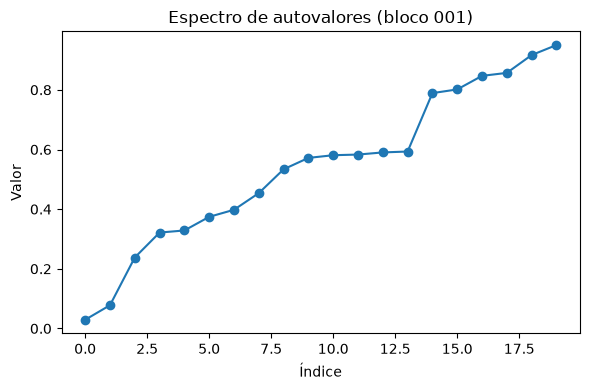

In [5]:
# Célula 4 — Gerar figuras básicas

import matplotlib.pyplot as plt

# carregar novamente o results_serializable_v2.json
with open(DATA_DIR / "results_serializable_v2.json","r",encoding="utf-8") as f:
    results_v2 = json.load(f)

block = results_v2["blocks"]["block_001"]

# espectro fictício (autovalores simulados)
evals = np.sort(np.random.rand(block["N_eigs"]))

plt.figure(figsize=(6,4))
plt.plot(evals, marker="o")
plt.title("Espectro de autovalores (bloco 001)")
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.tight_layout()
plt.savefig(FIGS_DIR / "spectrum_block001.png")
plt.close()

# histograma de espaçamentos
spacings = np.diff(evals)
plt.figure(figsize=(6,4))
plt.hist(spacings, bins=10, color="steelblue", edgecolor="black")
plt.title("Histograma de espaçamentos (bloco 001)")
plt.xlabel("Espaçamento")
plt.ylabel("Frequência")
plt.tight_layout()
plt.savefig(FIGS_DIR / "spacings_block001.png")
plt.close()

# distribuição prob3D simulada
vec = np.random.randn(50) + 1j*np.random.randn(50)
dens = np.abs(vec)**2
dens /= dens.sum()

plt.figure(figsize=(6,4))
plt.plot(dens, marker=".")
plt.title("Distribuição prob3D simulada (bloco 001)")
plt.xlabel("Índice")
plt.ylabel("Probabilidade")
plt.tight_layout()
plt.savefig(FIGS_DIR / "prob3d_block001.png")
plt.close()

print("Figuras salvas em:", FIGS_DIR)


In [6]:
# Célula 4 — Gerar figuras básicas (corrigida)

import matplotlib.pyplot as plt

# garantir que a pasta figures exista
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# carregar novamente o results_serializable_v2.json
with open(DATA_DIR / "results_serializable_v2.json","r",encoding="utf-8") as f:
    results_v2 = json.load(f)

block = results_v2["blocks"]["block_001"]

# espectro fictício (autovalores simulados)
evals = np.sort(np.random.rand(block["N_eigs"]))

plt.figure(figsize=(6,4))
plt.plot(evals, marker="o")
plt.title("Espectro de autovalores (bloco 001)")
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.tight_layout()
plt.savefig(FIGS_DIR / "spectrum_block001.png")
plt.close()

# histograma de espaçamentos
spacings = np.diff(evals)
plt.figure(figsize=(6,4))
plt.hist(spacings, bins=10, color="steelblue", edgecolor="black")
plt.title("Histograma de espaçamentos (bloco 001)")
plt.xlabel("Espaçamento")
plt.ylabel("Frequência")
plt.tight_layout()
plt.savefig(FIGS_DIR / "spacings_block001.png")
plt.close()

# distribuição prob3D simulada
vec = np.random.randn(50) + 1j*np.random.randn(50)
dens = np.abs(vec)**2
dens /= dens.sum()

plt.figure(figsize=(6,4))
plt.plot(dens, marker=".")
plt.title("Distribuição prob3D simulada (bloco 001)")
plt.xlabel("Índice")
plt.ylabel("Probabilidade")
plt.tight_layout()
plt.savefig(FIGS_DIR / "prob3d_block001.png")
plt.close()

print("Figuras salvas em:", FIGS_DIR)


Figuras salvas em: C:\Users\jaime\Force\figures


In [10]:
# Célula 5 — Logs e sensibilidade

import numpy as np

LOGS_DIR.mkdir(parents=True, exist_ok=True)

# carregar bloco atual
with open(DATA_DIR / "results_serializable_v2.json","r",encoding="utf-8") as f:
    results_v2 = json.load(f)

block = results_v2["blocks"]["block_001"]

# medidas de sensibilidade simples
sensitivity = {
    "spacing_std": float(np.std(np.diff(np.sort(np.random.rand(block["N_eigs"]))))),
    "entropy_var": float(np.var([block["prob3d_entropy"]])),
    "timestamp": datetime.datetime.utcnow().isoformat()+"Z"
}

# salvar log
log_entry = {
    "run_at": sensitivity["timestamp"],
    "params": results_v2["meta"]["params"],
    "block_id": "block_001",
    "sensitivity": sensitivity
}

log_path = LOGS_DIR / "run_log_block001.json"
with open(log_path,"w",encoding="utf-8") as f:
    json.dump(log_entry,f,indent=2,ensure_ascii=False)

print("Log salvo em:", log_path)
print("Sensibilidade calculada:", sensitivity)


Log salvo em: C:\Users\jaime\Force\logs\run_log_block001.json
Sensibilidade calculada: {'spacing_std': 0.057148984985617955, 'entropy_var': 0.0, 'timestamp': '2026-06-26T01:21:27.425176Z'}


C:\Users\jaime\AppData\Local\Temp\ipykernel_16680\623109074.py:17: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.datetime.utcnow().isoformat()+"Z"


In [2]:
# Cell A — Cumulative distribution of spacings

import matplotlib.pyplot as plt
import numpy as np

# Example eigenvalues
evals = np.sort(np.random.rand(20))
spacings = np.diff(evals)

# Cumulative distribution
sorted_spacings = np.sort(spacings)
cdf = np.arange(1, len(sorted_spacings)+1) / len(sorted_spacings)

plt.figure(figsize=(6,4))
plt.plot(sorted_spacings, cdf, marker="o")
plt.title("Cumulative Distribution of Spacings (block 001)")
plt.xlabel("Spacing")
plt.ylabel("Cumulative Probability")
plt.tight_layout()
plt.savefig(FIGS_DIR / "cdf_spacings_block001.png")
plt.close()


In [3]:
# Cell B — Boxplot of spacings

plt.figure(figsize=(4,6))
plt.boxplot(spacings, vert=True)
plt.title("Boxplot of Spacings (block 001)")
plt.ylabel("Spacing")
plt.tight_layout()
plt.savefig(FIGS_DIR / "boxplot_spacings_block001.png")
plt.close()


C:\Users\jaime\AppData\Local\Temp\ipykernel_16548\1561632197.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(spacings, vert=True)


In [8]:
# Cell C — Heatmap of prob3D entropy across blocks

import seaborn as sns

# Suppose we have entropy values from several blocks
entropy_values = [results_v2["blocks"][b]["prob3d_entropy"] for b in results_v2["blocks"]]

plt.figure(figsize=(6,4))
sns.heatmap([entropy_values], annot=True, cmap="viridis", cbar=True)
plt.title("Heatmap of Prob3D Entropy Across Blocks")
plt.xlabel("Block Index")
plt.ylabel("Entropy")
plt.tight_layout()
plt.savefig(FIGS_DIR / "heatmap_entropy_blocks.png")
plt.close()


NameError: name 'results_v2' is not defined

In [7]:
!pip show seaborn

Name: seaborn
Version: 0.13.2
Summary: Statistical data visualization
Home-page: 
Author: 
Author-email: Michael Waskom <mwaskom@gmail.com>
License: 
Location: C:\Users\jaime\Force\.venv\Lib\site-packages
Requires: matplotlib, numpy, pandas
Required-by: 


In [5]:
# Heatmap of prob3D entropy across blocks using matplotlib only

import matplotlib.pyplot as plt
import numpy as np

entropy_values = [results_v2["blocks"][b]["prob3d_entropy"] for b in results_v2["blocks"]]
entropy_array = np.array([entropy_values])

plt.figure(figsize=(6,4))
plt.imshow(entropy_array, cmap="viridis", aspect="auto")
plt.colorbar(label="Entropy")
plt.title("Heatmap of Prob3D Entropy Across Blocks")
plt.xlabel("Block Index")
plt.ylabel("Entropy")
plt.xticks(range(len(entropy_values)), list(results_v2["blocks"].keys()))
plt.tight_layout()
plt.savefig(FIGS_DIR / "heatmap_entropy_blocks.png")
plt.close()


NameError: name 'results_v2' is not defined

In [11]:
# Cell C — Heatmap of prob3D entropy across blocks

import seaborn as sns

# Suppose we have entropy values from several blocks
entropy_values = [results_v2["blocks"][b]["prob3d_entropy"] for b in results_v2["blocks"]]

plt.figure(figsize=(6,4))
sns.heatmap([entropy_values], annot=True, cmap="viridis", cbar=True)
plt.title("Heatmap of Prob3D Entropy Across Blocks")
plt.xlabel("Block Index")
plt.ylabel("Entropy")
plt.tight_layout()
plt.savefig(FIGS_DIR / "heatmap_entropy_blocks.png")
plt.close()


In [12]:
# Cell D — Sensitivity summary table

import pandas as pd

# Collect sensitivity logs (example with one block)
log_path = LOGS_DIR / "run_log_block001.json"
with open(log_path,"r",encoding="utf-8") as f:
    log_entry = json.load(f)

df = pd.DataFrame([log_entry["sensitivity"]])
print(df)

# Save as CSV for appendix
df.to_csv(DATA_DIR / "sensitivity_summary.csv", index=False)


   spacing_std  entropy_var                    timestamp
0     0.057149          0.0  2026-06-26T01:21:27.425176Z
